# 🚀 EDA Exploration — E-Commerce MMIX
Quick hands-on look at all datasets before building the pipeline.

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style("whitegrid")

DATA_DIR = '../data'

In [2]:
# Load all datasets
transactions = pd.read_csv(f'{DATA_DIR}/firstfile.csv')
sales = pd.read_csv(f'{DATA_DIR}/Sales.csv', sep='\t')  # Tab-delimited
monthly = pd.read_csv(f'{DATA_DIR}/SecondFile.csv')
special_sales = pd.read_csv(f'{DATA_DIR}/SpecialSale.csv')
investment = pd.read_csv(f'{DATA_DIR}/MediaInvestment.csv')
nps = pd.read_csv(f'{DATA_DIR}/MonthlyNPSscore.csv')
products = pd.read_csv(f'{DATA_DIR}/ProductList.csv')

# Remove index columns (Unnamed: 0)
for df in [transactions, sales, monthly, special_sales, investment, nps, products]:
    if 'Unnamed: 0' in df.columns:
        df.drop('Unnamed: 0', axis=1, inplace=True)

# Parse dates
transactions['Date'] = pd.to_datetime(transactions['Date'], errors='coerce')
sales['Date'] = pd.to_datetime(sales['Date'], format='%d-%m-%Y %H:%M', errors='coerce')
monthly['Date'] = pd.to_datetime(monthly['Date'], errors='coerce')
special_sales['Date'] = pd.to_datetime(special_sales['Date'], errors='coerce')
nps['Date'] = pd.to_datetime(nps['Date'], errors='coerce')

print("All loaded ✅")

All loaded ✅


## 2. Quick Look at Each Dataset

### 2a. Transactions (firstfile)

In [3]:
print(f"Shape: {transactions.shape}")
transactions.head(10)

Shape: (1578079, 9)


,Date,Sales_name,gmv_new,units,product_mrp,discount,product_category,product_subcategory,product_vertical
0,2015-07-01,No Promotion,3040.0,1,3650.0,610.0,EntertainmentSmall,HomeAudio,HomeAudioSpeaker
1,2015-07-01,No Promotion,310.0,1,400.0,90.0,EntertainmentSmall,Speaker,LaptopSpeaker
2,2015-07-01,No Promotion,1999.0,1,7999.0,6000.0,GamingHardware,GamingAccessory,GamePad
3,2015-07-01,No Promotion,139.0,1,700.0,561.0,EntertainmentSmall,TVVideoSmall,RemoteControl
4,2015-07-01,No Promotion,99.0,1,700.0,601.0,EntertainmentSmall,TVVideoSmall,RemoteControl
5,2015-07-01,No Promotion,428.0,1,999.0,571.0,GamingHardware,GamingAccessory,GamePad
6,2015-07-01,No Promotion,299.0,1,400.0,101.0,CameraAccessory,CameraStorage,CameraStorageMemoryCard
7,2015-07-01,No Promotion,305.0,1,1100.0,795.0,EntertainmentSmall,AudioMP3Player,AudioMP3Player
8,2015-07-01,No Promotion,396.0,4,2800.0,2404.0,EntertainmentSmall,TVVideoSmall,RemoteControl
9,2015-07-01,No Promotion,99.0,1,700.0,601.0,EntertainmentSmall,TVVideoSmall,RemoteControl


In [4]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1578079 entries, 0 to 1578078
Data columns (total 9 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   Date                 1578079 non-null  datetime64[ns]
 1   Sales_name           1578079 non-null  object        
 2   gmv_new              1578079 non-null  float64       
 3   units                1578079 non-null  int64         
 4   product_mrp          1578079 non-null  float64       
 5   discount             1578079 non-null  float64       
 6   product_category     1578079 non-null  object        
 7   product_subcategory  1578079 non-null  object        
 8   product_vertical     1578079 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 108.4+ MB


In [5]:
transactions.describe()

,Date,gmv_new,units,product_mrp,discount
count,1578079,1.578079e+06,1.578079e+06,1.578079e+06,1.578079e+06
mean,2016-01-10 02:42:45.394000640,2.461679e+03,1.021809e+00,4.257890e+03,1.796212e+03
min,2015-07-01 00:00:00,1.000000e+01,1.000000e+00,4.900000e+01,1.697040e-02
25%,2015-10-16 00:00:00,3.390000e+02,1.000000e+00,8.000000e+02,3.100000e+02
50%,2016-01-08 00:00:00,7.490000e+02,1.000000e+00,1.600000e+03,7.000000e+02
75%,2016-04-01 00:00:00,1.998000e+03,1.000000e+00,3.499000e+03,1.549000e+03
max,2016-06-30 00:00:00,2.269470e+05,5.000000e+01,4.200000e+05,4.183530e+05
std,NaN,5.640023e+03,2.493014e-01,8.793679e+03,4.276790e+03


In [6]:
transactions.isnull().sum()

Date                   0
Sales_name             0
gmv_new                0
units                  0
product_mrp            0
discount               0
product_category       0
product_subcategory    0
product_vertical       0
dtype: int64

In [7]:
# Unique values in key columns
print("Sales_name values:")
print(transactions['Sales_name'].value_counts())

Sales_name values:
Sales_name
No Promotion                 1291840
Daussera sale                  93417
Christmas & New Year Sale      42501
Big Diwali Sale                42365
Pacman                         25555
BSD-5                          25537
Republic Day                   22762
FHSD                           11792
Valentine's Day                 8074
BED                             7832
Eid & Rathayatra sale           6384
Rakshabandhan Sale                15
Independence Sale                  5
Name: count, dtype: int64


In [8]:
print("\nProduct categories:")
print(transactions['product_category'].value_counts())


Product categories:
product_category
EntertainmentSmall    918775
CameraAccessory       246499
GamingHardware        222773
Camera                 99301
GameCDDVD              90731
Name: count, dtype: int64


In [9]:
print("\nDate range:")
transactions['Date'] = pd.to_datetime(transactions['Date'])
print(f"  From: {transactions['Date'].min()}")
print(f"  To:   {transactions['Date'].max()}")


Date range:
  From: 2015-07-01 00:00:00
  To:   2016-06-30 00:00:00


### 2b. Sales

In [10]:
print(f"Shape: {sales.shape}")
sales.head(10)

Shape: (1048575, 13)


,ID,Date,ID_Order,ID_Item_ordered,GMV,Units_sold,SLA,Product_Category,Analytic_Category,Sub_category,product_analytic_vertical,MRP,Procurement_SLA
0,ACCCX3S58G7B5F6P,2015-10-17 15:11:00,3.420000e+15,3.420000e+15,6400,1,5,CE,CameraAccessory,CameraAccessory,CameraTripod,7190,0
1,ACCCX3S58G7B5F6P,2015-10-19 10:07:00,1.420000e+15,1.420000e+15,6900,1,7,CE,CameraAccessory,CameraAccessory,CameraTripod,7190,0
2,ACCCX3S5AHMF55FV,2015-10-20 15:45:00,2.420000e+15,2.420000e+15,1990,1,10,CE,CameraAccessory,CameraAccessory,CameraTripod,2099,3
3,ACCCX3S5AHMF55FV,2015-10-14 12:05:00,4.420000e+15,4.420000e+15,1690,1,4,CE,CameraAccessory,CameraAccessory,CameraTripod,2099,3
4,ACCCX3S5AHMF55FV,2015-10-17 21:25:00,4.420000e+15,4.420000e+15,1618,1,6,CE,CameraAccessory,CameraAccessory,CameraTripod,2099,3
5,ACCCX3S5JGAJETYR,2015-10-17 12:07:00,3.420000e+15,3.420000e+15,3324,1,5,CE,CameraAccessory,CameraAccessory,CameraTripod,4044,5
6,ACCCX3S5JGAJETYR,2015-10-16 14:59:00,3.420000e+15,3.420000e+15,3695,1,6,CE,CameraAccessory,CameraAccessory,CameraTripod,4044,5
7,ACCCX3S5JGAJETYR,2015-10-15 23:41:00,3.420000e+15,3.420000e+15,3695,1,5,CE,CameraAccessory,CameraAccessory,CameraTripod,4044,5
8,ACCCX3S5JGAJETYR,2015-10-16 00:49:00,2.420000e+15,2.420000e+15,,1,9,CE,CameraAccessory,CameraAccessory,CameraTripod,4044,5
9,ACCCX3S5JGAJETYR,2015-10-25 22:52:00,4.430000e+15,4.430000e+15,3695,1,7,CE,CameraAccessory,CameraAccessory,CameraTripod,4044,5


In [11]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 13 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   ID                         1048575 non-null  object        
 1   Date                       1048575 non-null  datetime64[ns]
 2   ID_Order                   1048575 non-null  float64       
 3   ID_Item_ordered            1048575 non-null  float64       
 4   GMV                        1048575 non-null  object        
 5   Units_sold                 1048575 non-null  int64         
 6   SLA                        1048575 non-null  int64         
 7   Product_Category           1048575 non-null  object        
 8   Analytic_Category          1048575 non-null  object        
 9   Sub_category               1048575 non-null  object        
 10  product_analytic_vertical  1048575 non-null  object        
 11  MRP                        1048575 no

In [12]:
sales.describe()

,Date,ID_Order,ID_Item_ordered,Units_sold,SLA,MRP,Procurement_SLA
count,1048575,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,2016-01-08 14:59:07.375266304,2.990225e+15,4.358168e+15,1.022597e+00,5.739834e+00,4.343884e+03,4.530773e+00
min,2015-08-30 13:17:00,7.633152e+07,1.080165e+08,1.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00
25%,2015-11-10 15:52:30,1.590000e+15,2.410000e+15,1.000000e+00,4.000000e+00,8.000000e+02,1.000000e+00
50%,2016-01-06 23:41:00,2.590000e+15,3.410000e+15,1.000000e+00,6.000000e+00,1.599000e+03,2.000000e+00
75%,2016-03-01 17:34:00,4.410000e+15,4.410000e+15,1.000000e+00,7.000000e+00,3.499000e+03,3.000000e+00
max,2016-06-11 11:52:00,4.590000e+15,3.000000e+17,5.000000e+01,1.840000e+02,2.800000e+05,1.000000e+03
std,NaN,1.119981e+15,2.014243e+16,2.717156e-01,2.734659e+00,8.858539e+03,4.453216e+01


In [13]:
sales.isnull().sum()

ID                           0
Date                         0
ID_Order                     0
ID_Item_ordered              0
GMV                          0
Units_sold                   0
SLA                          0
Product_Category             0
Analytic_Category            0
Sub_category                 0
product_analytic_vertical    0
MRP                          0
Procurement_SLA              0
dtype: int64

In [14]:
print("Product categories:")
print(sales['Product_Category'].value_counts() if 'Product_Category' in sales.columns else "Column not found")

Product categories:
Product_Category
CE    1048575
Name: count, dtype: int64


In [15]:
print("\nAnalytic categories:")
print(sales['Analytic_Category'].value_counts() if 'Analytic_Category' in sales.columns else "Column not found")


Analytic categories:
Analytic_Category
EntertainmentSmall    601384
CameraAccessory       160572
GamingHardware        145762
Camera                 72577
GameCDDVD              68280
Name: count, dtype: int64


### 2c. Monthly Aggregated (SecondFile) — ⭐ PRIMARY MODELING FILE

In [16]:
print(f"Shape: {monthly.shape}")
monthly.head()

Shape: (12, 39)


,month,Revenue_Camera,Revenue_CameraAccessory,Revenue_EntertainmentSmall,Revenue_GameCDDVD,Revenue_GamingHardware,total_gmv,Units_Camera,Units_CameraAccessory,Units_EntertainmentSmall,...,Digital,Sponsorship,Content.Marketing,Online.marketing,Affiliates,SEM,Radio,Other,Date,NPS
0,Jan 2016,1.869358e+08,2.638743e+07,1.093020e+08,1.688487e+07,4.770016e+07,3.872102e+08,10442,22525,81510,...,5000000.0,42000000.0,9000000.0,229000000.0,74000000.0,42000000.0,27000000.0,271000000.0,2016-01-01,47.1
1,Feb 2016,1.549989e+08,2.536880e+07,1.011725e+08,1.510002e+07,3.561454e+07,3.322547e+08,8606,25406,81292,...,19000000.0,117000000.0,6000000.0,199000000.0,65000000.0,49000000.0,NaN,NaN,2016-02-01,50.3
2,Mar 2016,1.861417e+08,2.676195e+07,1.202884e+08,2.299259e+07,4.802562e+07,4.042102e+08,9969,25484,84429,...,21000000.0,416000000.0,4000000.0,184000000.0,62000000.0,52000000.0,9000000.0,159000000.0,2016-03-01,49.0
3,Apr 2016,1.470531e+08,2.534451e+07,9.808951e+07,2.081085e+07,4.848195e+07,3.397800e+08,8006,25926,70521,...,9000000.0,243000000.0,0.0,165000000.0,57000000.0,42000000.0,NaN,NaN,2016-04-01,51.8
4,May 2016,1.844336e+08,3.052432e+07,1.104899e+08,2.434611e+07,5.967982e+07,4.094737e+08,9419,28820,81713,...,8000000.0,317000000.0,8000000.0,237000000.0,68000000.0,69000000.0,11000000.0,50000000.0,2016-05-01,47.3


In [17]:
monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   month                        12 non-null     object        
 1   Revenue_Camera               12 non-null     float64       
 2   Revenue_CameraAccessory      12 non-null     float64       
 3   Revenue_EntertainmentSmall   12 non-null     float64       
 4   Revenue_GameCDDVD            12 non-null     float64       
 5   Revenue_GamingHardware       12 non-null     float64       
 6   total_gmv                    12 non-null     float64       
 7   Units_Camera                 12 non-null     int64         
 8   Units_CameraAccessory        12 non-null     int64         
 9   Units_EntertainmentSmall     12 non-null     int64         
 10  Units_GameCDDVD              12 non-null     int64         
 11  Units_GamingHardware         12 non-null     in

In [18]:
monthly.describe()

,Revenue_Camera,Revenue_CameraAccessory,Revenue_EntertainmentSmall,Revenue_GameCDDVD,Revenue_GamingHardware,total_gmv,Units_Camera,Units_CameraAccessory,Units_EntertainmentSmall,Units_GameCDDVD,...,Digital,Sponsorship,Content.Marketing,Online.marketing,Affiliates,SEM,Radio,Other,Date,NPS
count,1.200000e+01,1.200000e+01,1.200000e+01,1.200000e+01,1.200000e+01,1.200000e+01,12.000000,12.000000,12.000000,12.000000,...,1.200000e+01,1.200000e+01,1.200000e+01,1.200000e+01,1.200000e+01,1.200000e+01,3.000000e+00,3.000000e+00,12,12.000000
mean,1.487230e+08,2.542880e+07,1.084462e+08,1.789728e+07,3.807569e+07,3.385709e+08,8528.166667,22103.333333,80016.916667,9856.583333,...,2.483333e+07,3.045000e+08,6.666667e+06,1.614167e+08,5.116667e+07,7.591667e+07,1.566667e+07,1.600000e+08,2015-12-16 08:00:00,49.558333
min,6.155000e+04,4.227800e+04,2.586660e+05,1.805400e+04,3.864800e+04,4.191960e+05,4.000000,38.000000,175.000000,8.000000,...,5.000000e+06,1.100000e+07,0.000000e+00,1.000000e+06,1.000000e+06,2.500000e+07,9.000000e+06,5.000000e+07,2015-07-01 00:00:00,44.400000
25%,1.349280e+08,2.341402e+07,9.710295e+07,1.643866e+07,3.317078e+07,3.256713e+08,7664.000000,19960.750000,69713.500000,8830.250000,...,1.200000e+07,1.062500e+08,0.000000e+00,1.430000e+08,4.450000e+07,4.200000e+07,1.000000e+07,1.045000e+08,2015-09-23 12:00:00,46.975000
50%,1.592958e+08,2.587812e+07,1.052372e+08,2.006060e+07,3.996560e+07,3.634951e+08,9160.000000,23965.500000,81401.000000,10507.000000,...,1.400000e+07,2.465000e+08,5.000000e+06,1.900000e+08,6.350000e+07,5.100000e+07,1.100000e+07,1.590000e+08,2015-12-16 12:00:00,48.150000
75%,1.863402e+08,2.909359e+07,1.213991e+08,2.193150e+07,4.813970e+07,4.137274e+08,10087.250000,26216.500000,87458.000000,12193.000000,...,2.200000e+07,4.537500e+08,8.250000e+06,2.260000e+08,6.800000e+07,6.375000e+07,1.900000e+07,2.150000e+08,2016-03-08 18:00:00,50.825000
max,2.427325e+08,4.620538e+07,1.817664e+08,2.477973e+07,5.967982e+07,5.095323e+08,15726.000000,36051.000000,133872.000000,14472.000000,...,1.260000e+08,8.470000e+08,3.400000e+07,2.440000e+08,7.400000e+07,3.190000e+08,2.700000e+07,2.710000e+08,2016-06-01 00:00:00,60.000000
std,6.728952e+07,1.059202e+07,4.613655e+07,6.936918e+06,1.638798e+07,1.347638e+08,3940.532309,8974.369700,33853.451594,3972.937188,...,3.270205e+07,2.623230e+08,9.442008e+06,8.456892e+07,2.556928e+07,7.953325e+07,9.865766e+06,1.105034e+08,NaN,4.334944


In [19]:
monthly.isnull().sum()

month                          0
Revenue_Camera                 0
Revenue_CameraAccessory        0
Revenue_EntertainmentSmall     0
Revenue_GameCDDVD              0
Revenue_GamingHardware         0
total_gmv                      0
Units_Camera                   0
Units_CameraAccessory          0
Units_EntertainmentSmall       0
Units_GameCDDVD                0
Units_GamingHardware           0
total_Units                    0
Mrp_Camera                     0
Mrp_CameraAccessory            0
Mrp_EntertainmentSmall         0
Mrp_GameCDDVD                  0
Mrp_GamingHardware             0
total_Mrp                      0
Discount_Camera                0
Discount_CameraAccessory       0
Discount_EntertainmentSmall    0
Discount_GameCDDVD             0
Discount_GamingHardware        0
total_Discount                 0
Year                           0
Month                          0
Total.Investment               0
TV                             0
Digital                        0
Sponsorshi

In [20]:
monthly.columns.tolist()

['month',
 'Revenue_Camera',
 'Revenue_CameraAccessory',
 'Revenue_EntertainmentSmall',
 'Revenue_GameCDDVD',
 'Revenue_GamingHardware',
 'total_gmv',
 'Units_Camera',
 'Units_CameraAccessory',
 'Units_EntertainmentSmall',
 'Units_GameCDDVD',
 'Units_GamingHardware',
 'total_Units',
 'Mrp_Camera',
 'Mrp_CameraAccessory',
 'Mrp_EntertainmentSmall',
 'Mrp_GameCDDVD',
 'Mrp_GamingHardware',
 'total_Mrp',
 'Discount_Camera',
 'Discount_CameraAccessory',
 'Discount_EntertainmentSmall',
 'Discount_GameCDDVD',
 'Discount_GamingHardware',
 'total_Discount',
 'Year',
 'Month',
 'Total.Investment',
 'TV',
 'Digital',
 'Sponsorship',
 'Content.Marketing',
 'Online.marketing',
 'Affiliates',
 'SEM',
 'Radio',
 'Other',
 'Date',
 'NPS']

### 2d. Special Sales

In [21]:
print(f"Shape: {special_sales.shape}")
special_sales

Shape: (44, 2)


,Date,Sales Name
0,2015-07-18,Eid & Rathayatra sale
1,2015-07-19,Eid & Rathayatra sale
2,2015-08-15,Independence Sale
3,2015-08-16,Independence Sale
4,2015-08-17,Independence Sale
5,2015-08-28,Rakshabandhan Sale
6,2015-08-29,Rakshabandhan Sale
7,2015-08-30,Rakshabandhan Sale
8,2015-10-15,Daussera sale
9,2015-10-16,Daussera sale


In [22]:
special_sales['Sales Name'].value_counts()

Sales Name
Christmas & New Year Sale    10
Big Diwali Sale               8
Independence Sale             3
Rakshabandhan Sale            3
BSD-5                         3
Daussera sale                 3
Republic Day                  3
Pacman                        3
Eid & Rathayatra sale         2
BED                           2
FHSD                          2
Valentine's Day               2
Name: count, dtype: int64

### 2e. Media Investment

In [23]:
print(f"Shape: {investment.shape}")
investment

Shape: (12, 12)


,Year,Month,Total Investment,TV,Digital,Sponsorship,Content Marketing,Online marketing,Affiliates,SEM,Radio,Other
0,2015,7,17.1,0.2,2.5,7.4,0.0,1.3,0.5,5.0,NaN,NaN
1,2015,8,5.1,0.0,1.3,1.1,0.0,0.1,0.1,2.5,NaN,NaN
2,2015,9,96.3,3.9,1.4,62.8,0.6,16.4,5.0,6.2,NaN,NaN
3,2015,10,170.2,6.1,12.6,84.7,3.4,24.4,7.0,31.9,NaN,NaN
4,2015,11,51.2,4.2,1.3,14.2,0.2,19.6,6.6,5.2,NaN,NaN
5,2015,12,106.7,5.4,3.1,56.7,1.1,22.5,6.8,11.2,NaN,NaN
6,2016,1,74.2,4.4,0.5,4.2,0.9,22.9,7.4,4.2,2.7,27.1
7,2016,2,48.1,2.6,1.9,11.7,0.6,19.9,6.5,4.9,NaN,NaN
8,2016,3,100.0,9.3,2.1,41.6,0.4,18.4,6.2,5.2,0.9,15.9
9,2016,4,56.8,5.2,0.9,24.3,0.0,16.5,5.7,4.2,NaN,NaN


In [24]:
investment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               12 non-null     int64  
 1   Month              12 non-null     int64  
 2   Total Investment   12 non-null     float64
 3   TV                 12 non-null     float64
 4   Digital            12 non-null     float64
 5   Sponsorship        12 non-null     float64
 6   Content Marketing  12 non-null     float64
 7   Online marketing   12 non-null     float64
 8    Affiliates        12 non-null     float64
 9   SEM                12 non-null     float64
 10  Radio              3 non-null      float64
 11  Other              3 non-null      float64
dtypes: float64(10), int64(2)
memory usage: 1.2 KB


In [25]:
investment.isnull().sum()

Year                 0
Month                0
Total Investment     0
TV                   0
Digital              0
Sponsorship          0
Content Marketing    0
Online marketing     0
 Affiliates          0
SEM                  0
Radio                9
Other                9
dtype: int64

### 2f. Monthly NPS

In [26]:
print(f"Shape: {nps.shape}")
nps

Shape: (12, 2)


,Date,NPS
0,2015-07-01,54.6
1,2015-08-01,60.0
2,2015-09-01,46.9
3,2015-10-01,44.4
4,2015-11-01,47.0
5,2015-12-01,45.8
6,2016-01-01,47.1
7,2016-02-01,50.3
8,2016-03-01,49.0
9,2016-04-01,51.8


### 2g. Product List

In [27]:
print(f"Shape: {products.shape}")
products.head(20)

Shape: (75, 3)


,Product,Frequency,Percent
0,\N,5828,0.4
1,AmplifierReceiver,4056,0.2
2,AudioMP3Player,112892,6.8
3,Binoculars,14599,0.9
4,BoomBox,2879,0.2
5,Camcorders,987,0.1
6,CameraAccessory,2269,0.1
7,CameraBag,17523,1.1
8,CameraBattery,41307,2.5
9,CameraBatteryCharger,15660,0.9


In [28]:
# Top 15 products by frequency
products.sort_values('Frequency', ascending=False).head(15)

,Product,Frequency,Percent
5,Camcorders,987,0.1
11,CameraEyeCup,98,0.0
33,GameValueCards,97,0.0
37,GamingConsole,9676,0.6
34,GamingAccessoryKit,9508,0.6
20,CodeInTheBoxGame,9345,0.6
54,Microphone,9079,0.6
26,ExtensionTube,87,0.0
47,HomeAudioSpeaker,85607,5.2
70,TVOutCableAccessory,7618,0.5


---
## 3. National-Level Trends

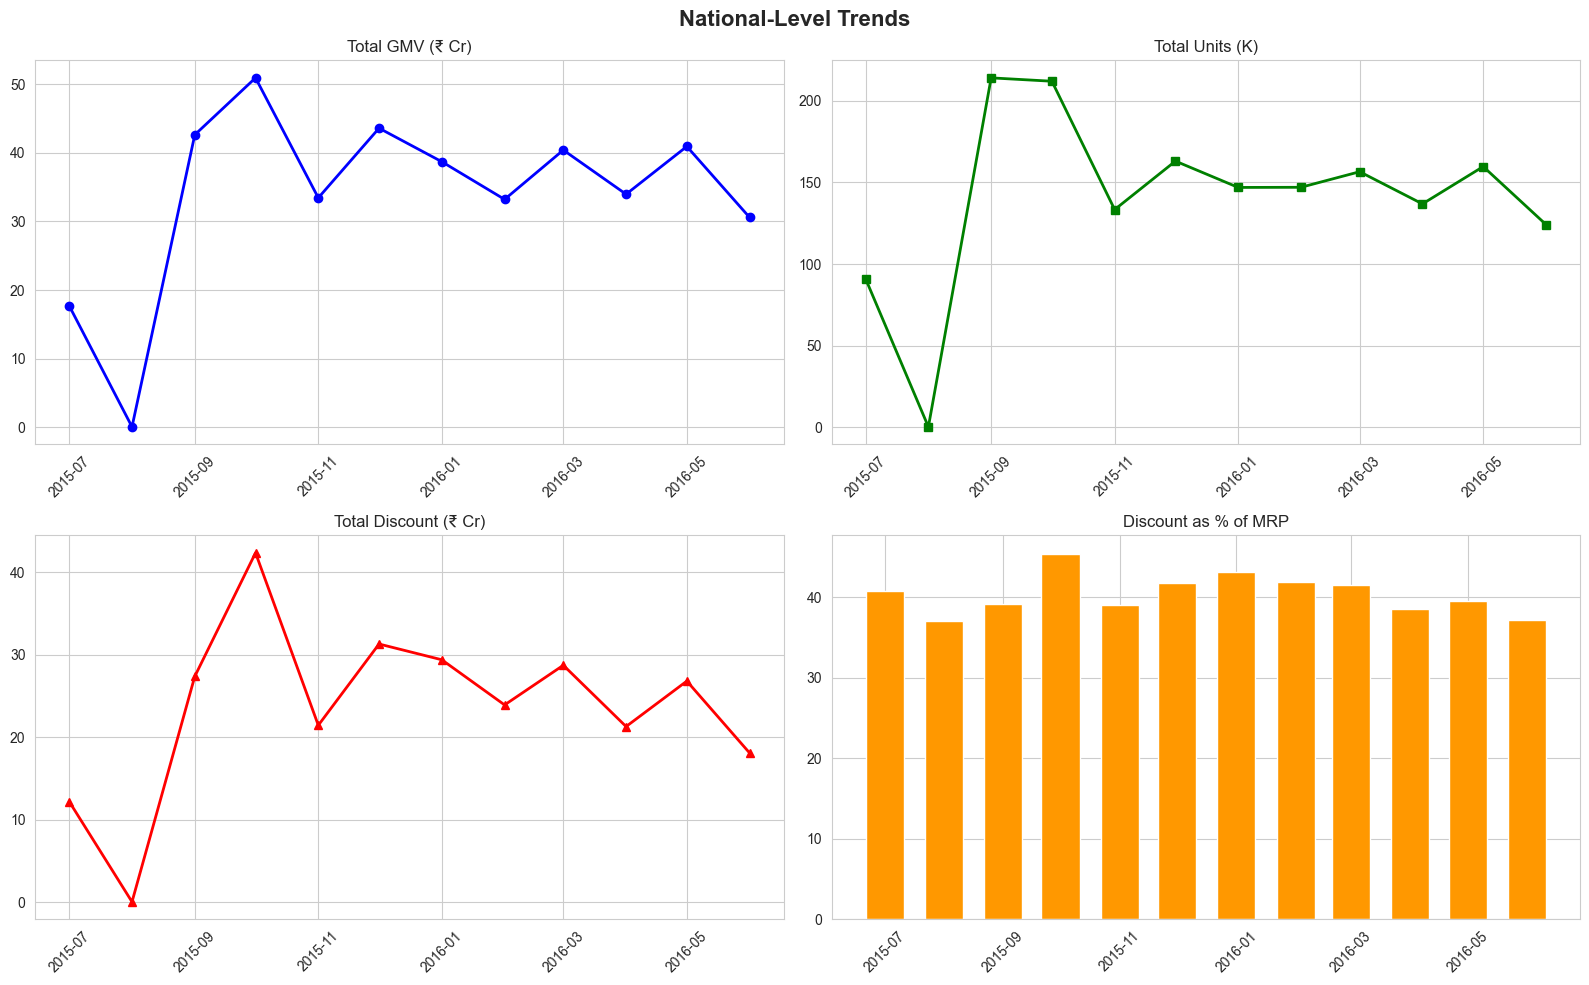

In [29]:
monthly['Date'] = pd.to_datetime(monthly['Date'])
m = monthly.sort_values('Date')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('National-Level Trends', fontsize=16, fontweight='bold')

axes[0,0].plot(m['Date'], m['total_gmv']/1e7, 'b-o', lw=2)
axes[0,0].set_title('Total GMV (₹ Cr)')
axes[0,0].tick_params(axis='x', rotation=45)

axes[0,1].plot(m['Date'], m['total_Units']/1e3, 'g-s', lw=2)
axes[0,1].set_title('Total Units (K)')
axes[0,1].tick_params(axis='x', rotation=45)

axes[1,0].plot(m['Date'], m['total_Discount']/1e7, 'r-^', lw=2)
axes[1,0].set_title('Total Discount (₹ Cr)')
axes[1,0].tick_params(axis='x', rotation=45)

m['disc_pct'] = m['total_Discount'] / m['total_Mrp'] * 100
axes[1,1].bar(m['Date'], m['disc_pct'], color='#FF9800', width=20)
axes[1,1].set_title('Discount as % of MRP')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Category-Level Revenue

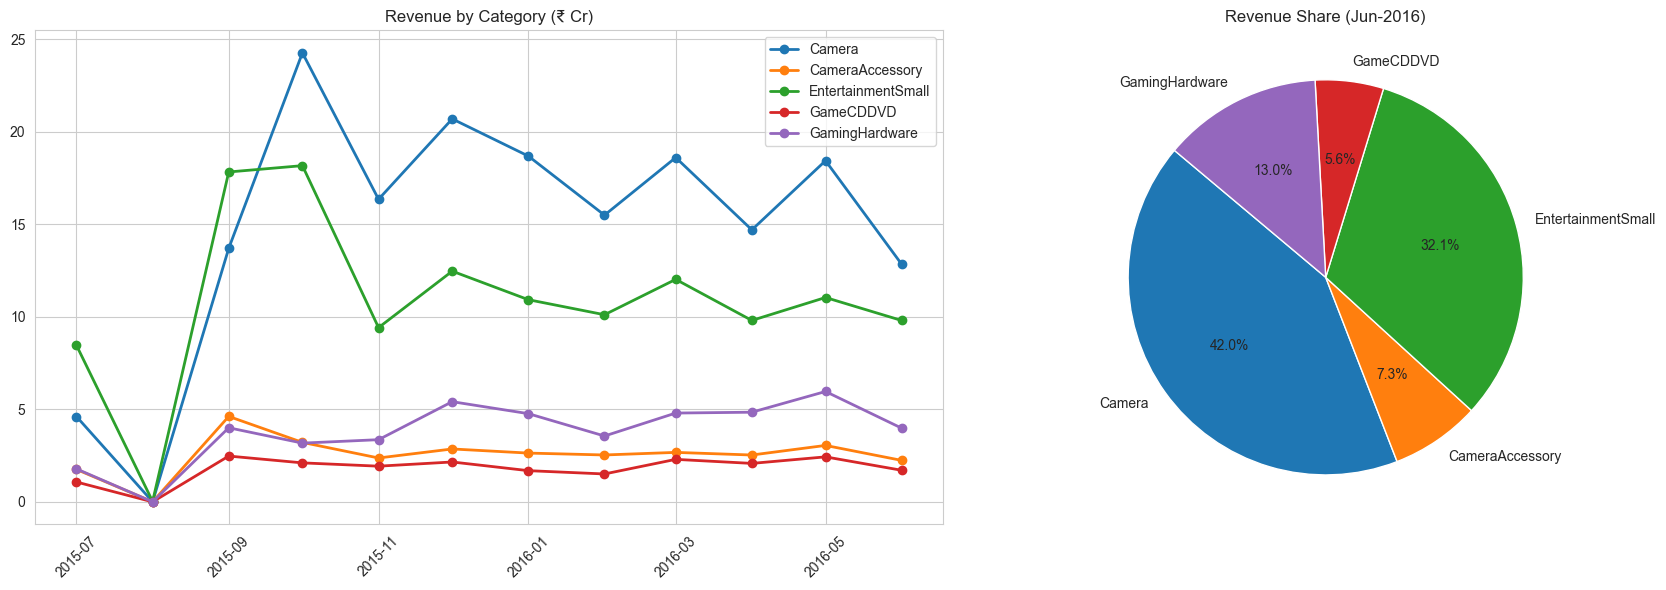

In [30]:
rev_cols = [c for c in m.columns if c.startswith('Revenue_')]
categories = [c.replace('Revenue_', '') for c in rev_cols]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for col, cat in zip(rev_cols, categories):
    axes[0].plot(m['Date'], m[col]/1e7, marker='o', label=cat, lw=2)
axes[0].set_title('Revenue by Category (₹ Cr)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Latest month share
latest = m.iloc[-1]
axes[1].pie([latest[c] for c in rev_cols], labels=categories,
            autopct='%1.1f%%', startangle=140)
axes[1].set_title(f'Revenue Share ({latest["Date"].strftime("%b-%Y")})')

plt.tight_layout()
plt.show()

## 5. Media Investment Analysis

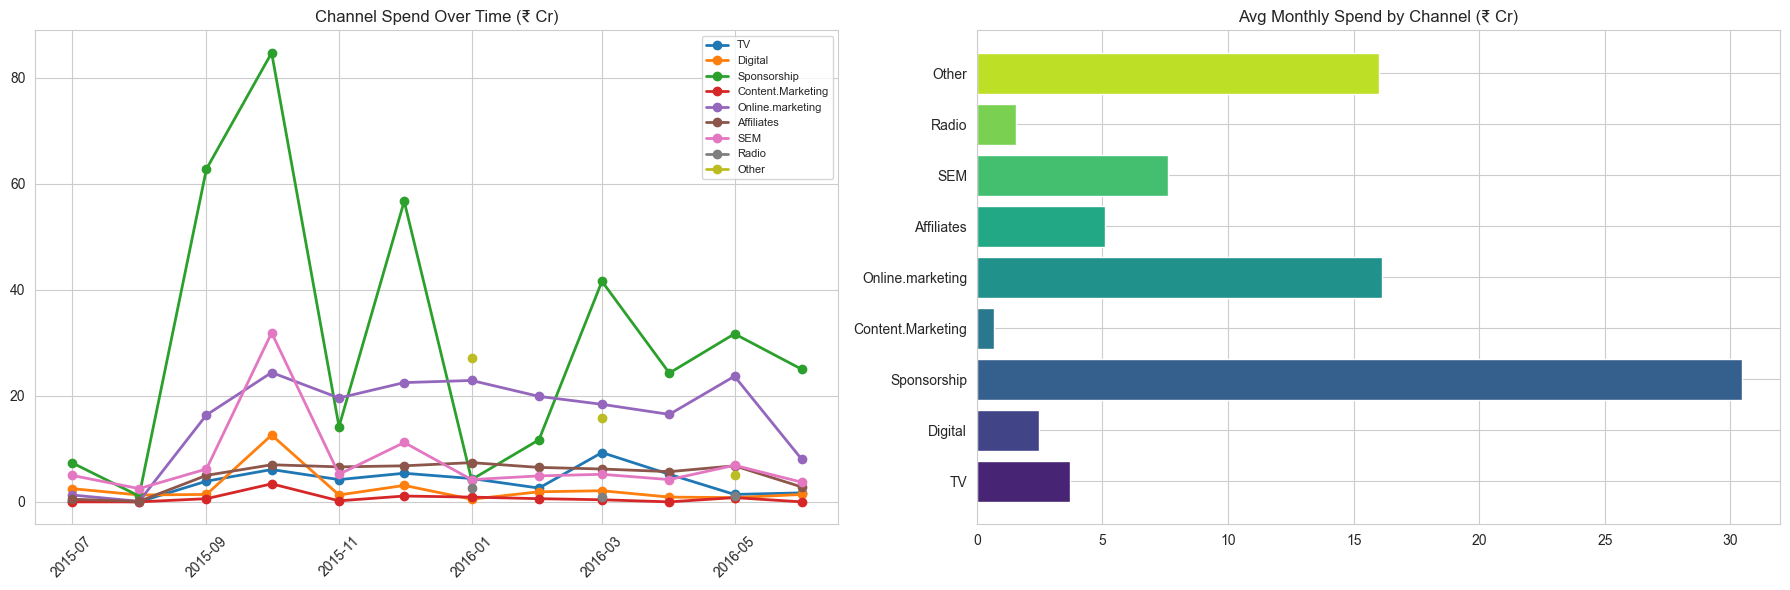

Share of Spend:
  Sponsorship               → ₹30.4 Cr (36.4%)
  Online.marketing          → ₹16.1 Cr (19.3%)
  Other                     → ₹16.0 Cr (19.1%)
  SEM                       → ₹7.6 Cr (9.1%)
  Affiliates                → ₹5.1 Cr (6.1%)
  TV                        → ₹3.7 Cr (4.4%)
  Digital                   → ₹2.5 Cr (3.0%)
  Radio                     → ₹1.6 Cr (1.9%)
  Content.Marketing         → ₹0.7 Cr (0.8%)


In [31]:
channels = ['TV', 'Digital', 'Sponsorship', 'Content.Marketing',
            'Online.marketing', 'Affiliates', 'SEM', 'Radio', 'Other']
ch_present = [c for c in channels if c in m.columns]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ch in ch_present:
    vals = pd.to_numeric(m[ch], errors='coerce') / 1e7
    axes[0].plot(m['Date'], vals, marker='o', label=ch, lw=2)
axes[0].set_title('Channel Spend Over Time (₹ Cr)')
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=45)

avg = {ch: pd.to_numeric(m[ch], errors='coerce').mean() for ch in ch_present}
avg = {k: v for k, v in avg.items() if not np.isnan(v)}
axes[1].barh(list(avg.keys()), [v/1e7 for v in avg.values()],
             color=sns.color_palette("viridis", len(avg)))
axes[1].set_title('Avg Monthly Spend by Channel (₹ Cr)')

plt.tight_layout()
plt.show()

# Share of spend
total = sum(avg.values())
print("Share of Spend:")
for ch, v in sorted(avg.items(), key=lambda x: -x[1]):
    print(f"  {ch:25s} → ₹{v/1e7:.1f} Cr ({v/total*100:.1f}%)")

## 6. Correlation Analysis — Media vs Revenue

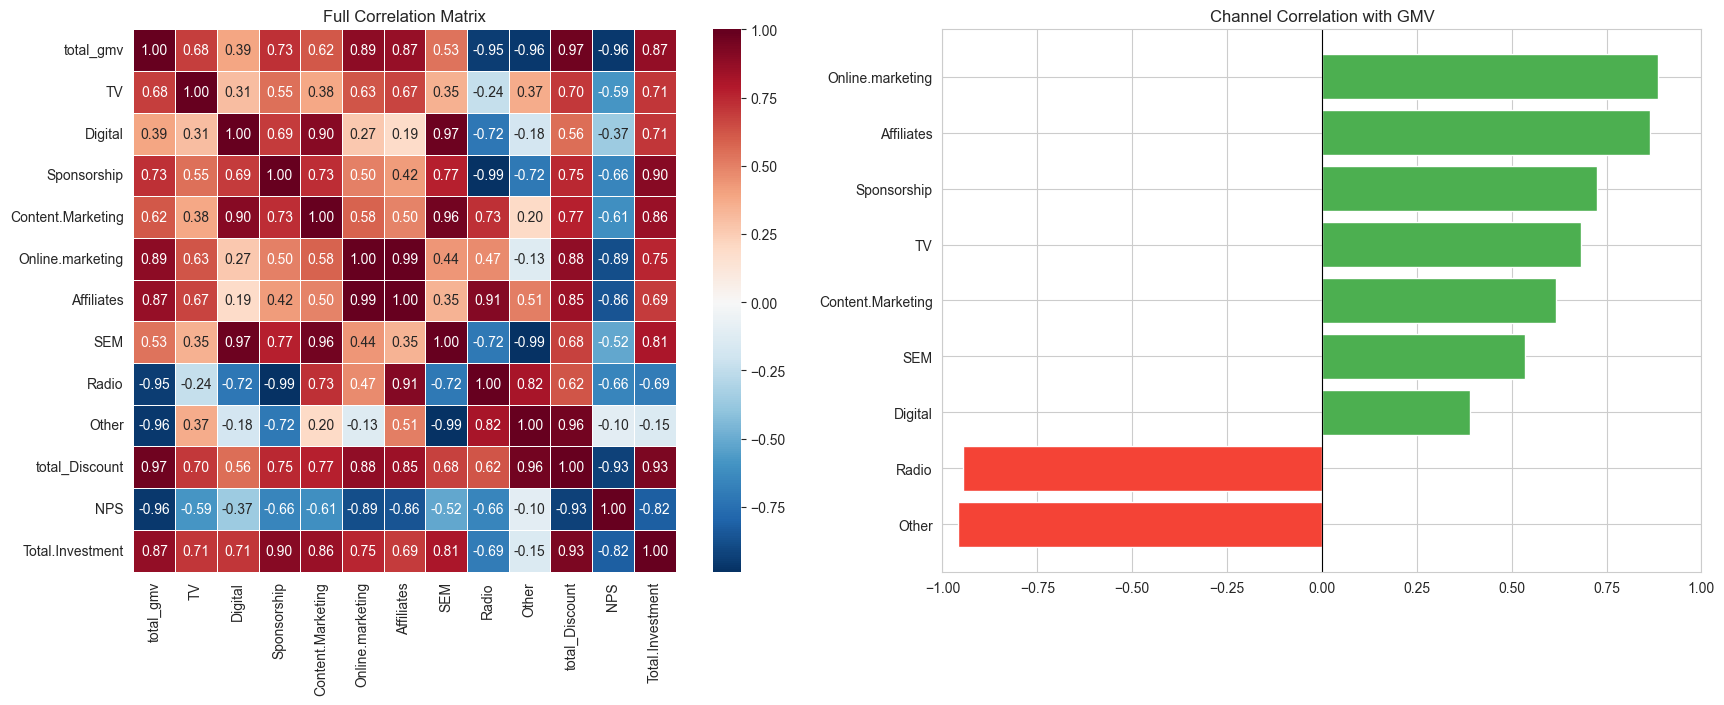


Channel Correlations with GMV:
  Other                     → -0.959 (strong)
  Radio                     → -0.946 (strong)
  Digital                   → +0.390 (moderate)
  SEM                       → +0.535 (moderate)
  Content.Marketing         → +0.617 (strong)
  TV                        → +0.683 (strong)
  Sponsorship               → +0.726 (strong)
  Affiliates                → +0.866 (strong)
  Online.marketing          → +0.887 (strong)


In [32]:
target = 'total_gmv'
extra = ['total_Discount', 'NPS', 'Total.Investment']
all_vars = [target] + ch_present + [v for v in extra if v in m.columns]

corr_df = m[all_vars].apply(pd.to_numeric, errors='coerce')
corr_matrix = corr_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Full Correlation Matrix')

ch_corr = corr_matrix.loc[ch_present, target].sort_values()
colors = ['#4CAF50' if v > 0 else '#F44336' for v in ch_corr.values]
axes[1].barh(ch_corr.index, ch_corr.values, color=colors)
axes[1].set_title(f'Channel Correlation with GMV')
axes[1].axvline(x=0, color='black', lw=0.8)
axes[1].set_xlim(-1, 1)

plt.tight_layout()
plt.show()

print("\nChannel Correlations with GMV:")
for ch, val in ch_corr.items():
    strength = "strong" if abs(val) > 0.6 else "moderate" if abs(val) > 0.3 else "weak"
    print(f"  {ch:25s} → {val:+.3f} ({strength})")

## 7. Special Sale Impact

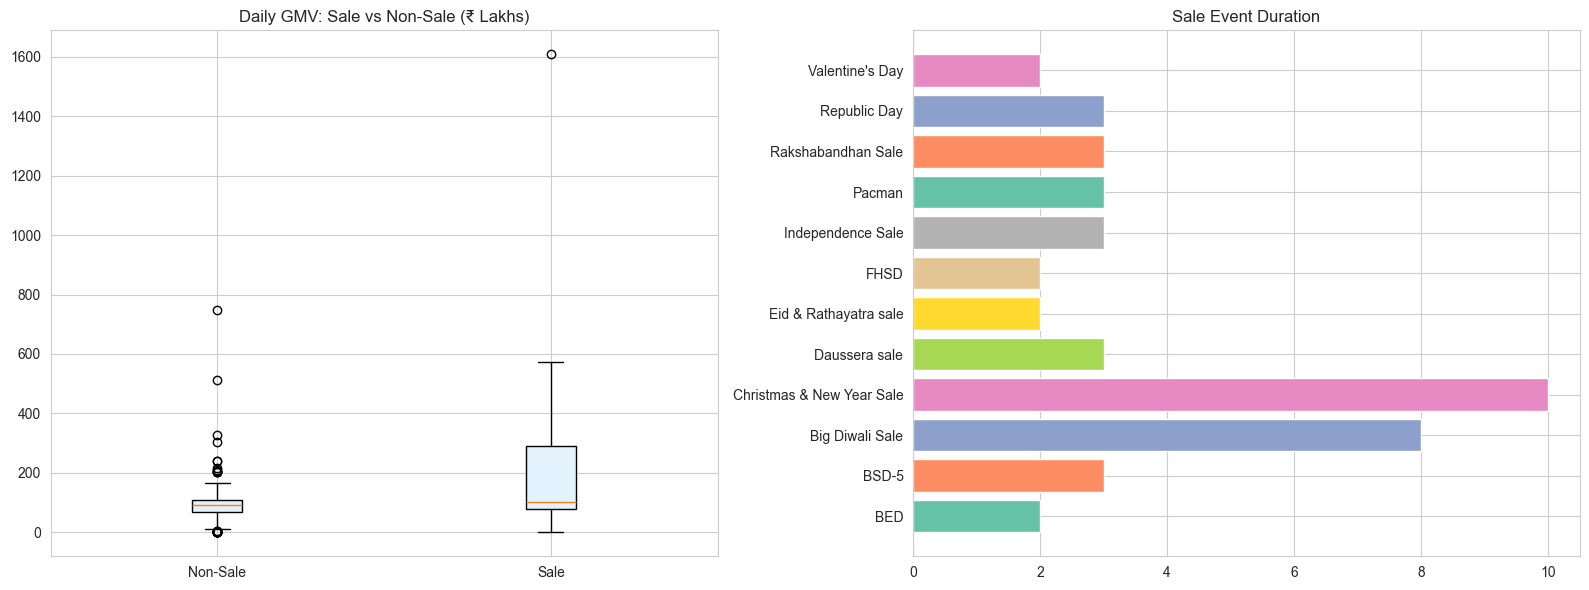

Non-Sale Avg GMV: ₹94.5L
Sale Avg GMV:     ₹204.5L
Sale Lift:        +116.5%


In [33]:
tx = transactions.copy()
tx['Date'] = pd.to_datetime(tx['Date'])
ss = special_sales.copy()
ss['Date'] = pd.to_datetime(ss['Date'])

sale_dates = set(ss['Date'].dt.date)
tx['is_sale'] = tx['Date'].dt.date.apply(lambda d: d in sale_dates)

daily = tx.groupby(['Date', 'is_sale']).agg(
    daily_gmv=('gmv_new', 'sum'),
    daily_units=('units', 'sum')
).reset_index()

sale_gmv = daily[daily['is_sale']]['daily_gmv'].values
nonsale_gmv = daily[~daily['is_sale']]['daily_gmv'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].boxplot([nonsale_gmv/1e5, sale_gmv/1e5],
                labels=['Non-Sale', 'Sale'],
                patch_artist=True,
                boxprops=dict(facecolor='#E3F2FD'))
axes[0].set_title('Daily GMV: Sale vs Non-Sale (₹ Lakhs)')

ss_summary = ss.groupby('Sales Name').size().reset_index(name='Days')
axes[1].barh(ss_summary['Sales Name'], ss_summary['Days'],
             color=sns.color_palette("Set2", len(ss_summary)))
axes[1].set_title('Sale Event Duration')

plt.tight_layout()
plt.show()

if len(sale_gmv) > 0:
    lift = (sale_gmv.mean() / nonsale_gmv.mean() - 1) * 100
    print(f"Non-Sale Avg GMV: ₹{nonsale_gmv.mean()/1e5:.1f}L")
    print(f"Sale Avg GMV:     ₹{sale_gmv.mean()/1e5:.1f}L")
    print(f"Sale Lift:        {lift:+.1f}%")

## 8. Traditional vs Digital Channels

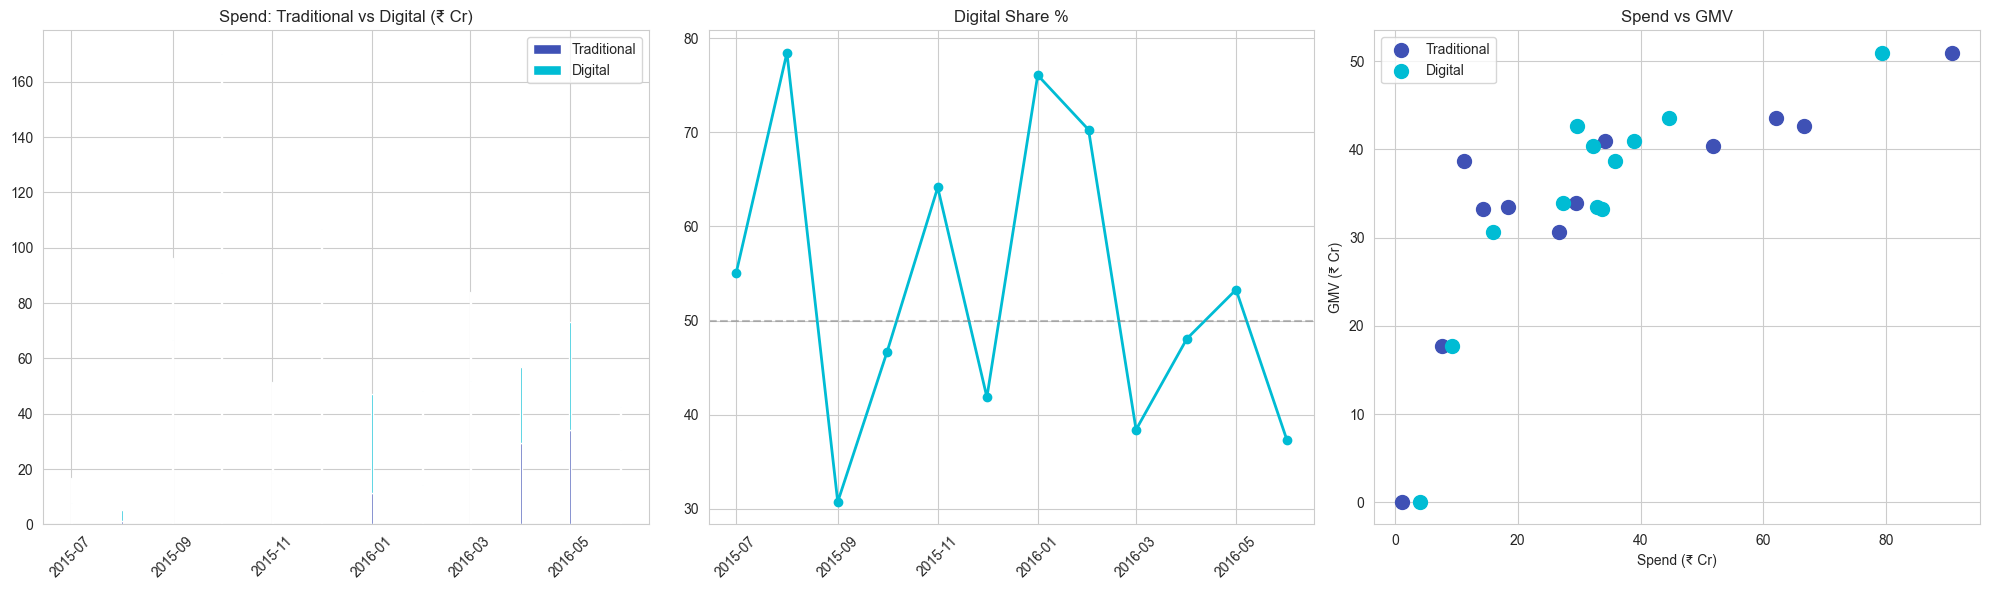

Avg Traditional: ₹34.5 Cr/month
Avg Digital:     ₹32.0 Cr/month
Avg Digital Share: 53.4%


In [34]:
traditional = ['TV', 'Radio', 'Sponsorship']
digital = ['Digital', 'Online.marketing', 'Affiliates', 'SEM', 'Content.Marketing']

trad = [c for c in traditional if c in m.columns]
digi = [c for c in digital if c in m.columns]

m['trad_spend'] = m[trad].apply(pd.to_numeric, errors='coerce').sum(axis=1)
m['digi_spend'] = m[digi].apply(pd.to_numeric, errors='coerce').sum(axis=1)
m['digi_share'] = m['digi_spend'] / (m['trad_spend'] + m['digi_spend']) * 100

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].bar(m['Date'], m['trad_spend']/1e7, label='Traditional', color='#3F51B5')
axes[0].bar(m['Date'], m['digi_spend']/1e7, bottom=m['trad_spend']/1e7,
            label='Digital', color='#00BCD4')
axes[0].set_title('Spend: Traditional vs Digital (₹ Cr)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(m['Date'], m['digi_share'], 'o-', color='#00BCD4', lw=2)
axes[1].set_title('Digital Share %')
axes[1].axhline(y=50, color='gray', ls='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=45)

axes[2].scatter(m['trad_spend']/1e7, m['total_gmv']/1e7, s=100, label='Traditional', color='#3F51B5')
axes[2].scatter(m['digi_spend']/1e7, m['total_gmv']/1e7, s=100, label='Digital', color='#00BCD4')
axes[2].set_title('Spend vs GMV')
axes[2].set_xlabel('Spend (₹ Cr)')
axes[2].set_ylabel('GMV (₹ Cr)')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Avg Traditional: ₹{m['trad_spend'].mean()/1e7:.1f} Cr/month")
print(f"Avg Digital:     ₹{m['digi_spend'].mean()/1e7:.1f} Cr/month")
print(f"Avg Digital Share: {m['digi_share'].mean():.1f}%")

## 9. NPS vs Revenue

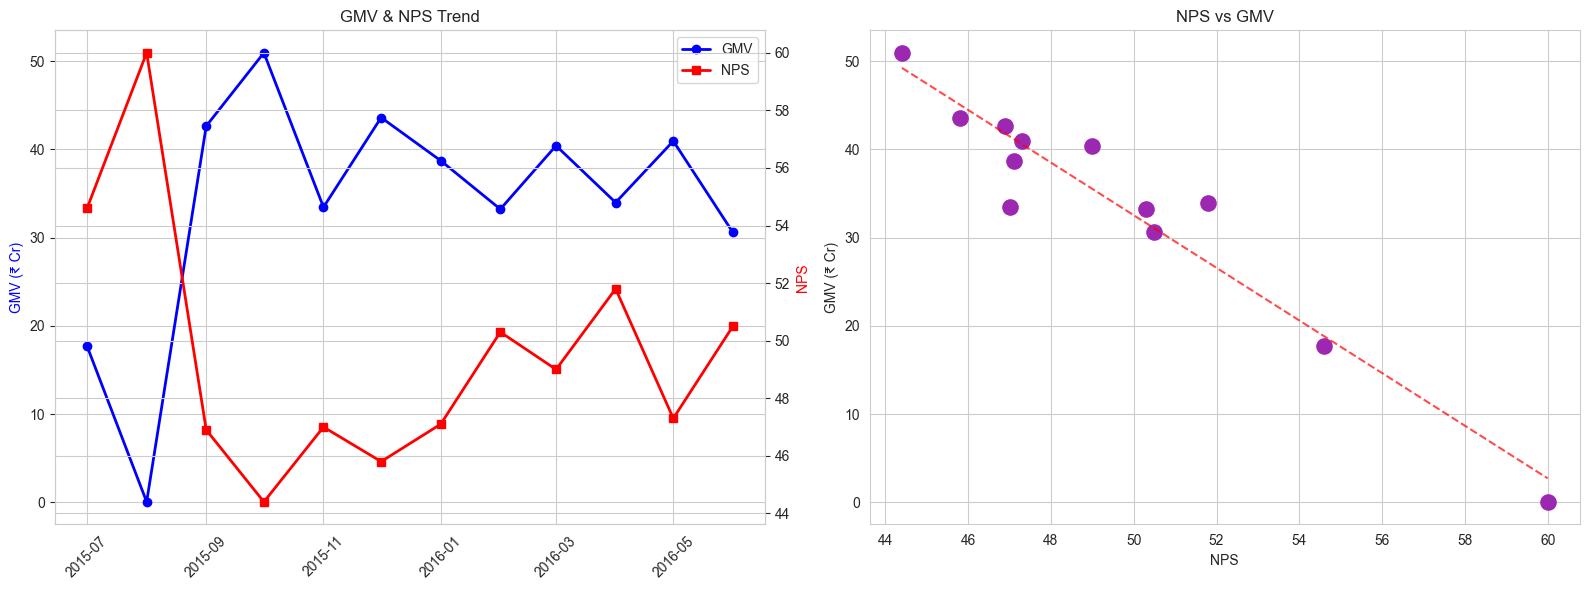

NPS-GMV Correlation: -0.960


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(m['Date'], m['total_gmv']/1e7, 'b-o', label='GMV', lw=2)
ax2.plot(m['Date'], m['NPS'], 'r-s', label='NPS', lw=2)
ax1.set_ylabel('GMV (₹ Cr)', color='blue')
ax2.set_ylabel('NPS', color='red')
ax1.set_title('GMV & NPS Trend')
ax1.tick_params(axis='x', rotation=45)
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2)

axes[1].scatter(m['NPS'], m['total_gmv']/1e7, s=120, c='#9C27B0')
z = np.polyfit(m['NPS'].dropna(), m.loc[m['NPS'].notna(), 'total_gmv']/1e7, 1)
p = np.poly1d(z)
x_line = np.linspace(m['NPS'].min(), m['NPS'].max(), 50)
axes[1].plot(x_line, p(x_line), 'r--', alpha=0.7)
axes[1].set_title('NPS vs GMV')
axes[1].set_xlabel('NPS')
axes[1].set_ylabel('GMV (₹ Cr)')

plt.tight_layout()
plt.show()

corr = m['NPS'].corr(m['total_gmv'])
print(f"NPS-GMV Correlation: {corr:.3f}")

## 10. Quick Data Summary
Key observations to carry into modeling.

In [36]:
print("=" * 60)
print("📋 KEY DATA SUMMARY")
print("=" * 60)
print(f"\nTime range:      {m['Date'].min().strftime('%b-%Y')} to {m['Date'].max().strftime('%b-%Y')}")
print(f"Months of data:  {len(m)}")

📋 KEY DATA SUMMARY

Time range:      Jul-2015 to Jun-2016
Months of data:  12
